In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn



from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score

from transformers import AutoTokenizer, AutoModel
import unicodedata
import re

from torch_geometric.data import Data



import matplotlib.pyplot as plt

import seaborn as sns
import pickle
from collections import Counter
from model_def import GCNNet

from embed_utils import embed_combined ,embed_batch
from train_utils import train_epoch_inductive, eval_epoch_inductive

c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\venv-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("Memory:", torch.cuda.memory_allocated())

CUDA: True
GPU: NVIDIA GeForce GTX 1650
Memory: 0


part Import 

pip install --quiet transformers
pip install torch
pip install pandas
pip install pythainlp


Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}

In [3]:
# ════════════════════════════════════════════
# STEP 1 — Load & Clean Data
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 1 | Load & Clean Data")
print("="*60)
 
# ── 1.1 ตัวอักษรพิเศษที่ต้องกัน ──────────────────────────
ZW = ''.join(['\u200B', '\u200C', '\u200D', '\uFEFF'])
 
def normalize_thai(s):
    """ทำความสะอาดข้อความภาษาไทย (NFC, whitespace, zero-width, diacritics)"""
    if pd.isna(s):
        return None
    s = str(s).replace('\u00A0', ' ').translate({ord(ch): None for ch in ZW})
    s = unicodedata.normalize('NFC', s)
    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'([\u0E31\u0E34-\u0E3A\u0E47-\u0E4E])\1+', r'\1', s)
    return s
 
# ── 1.2 โหลดข้อมูล ────────────────────────────────────────
df = pd.read_csv('AFNC_news_dataset_tf-2.csv')
df.columns = df.columns.str.strip()
 
# ── 1.3 ทำความสะอาด label & category ─────────────────────
df['ประเภทข่าว']    = df['ประเภทข่าว'].apply(normalize_thai)
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].apply(normalize_thai)
 
# ── 1.4 Label mapping ─────────────────────────────────────
df = df.dropna(subset=['หัวข้อข่าว', 'ประเภทข่าว', 'หมวดหมู่ของข่าว']).reset_index(drop=True)
 
classes  = sorted(df['ประเภทข่าว'].unique())         # ['ข่าวจริง', 'ข่าวปลอม']
label2id = {c: i for i, c in enumerate(classes)}    # {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {i: c for c, i in label2id.items()}
 
cats    = sorted(df['หมวดหมู่ของข่าว'].unique())
cat2id  = {c: i for i, c in enumerate(cats)}
id2cat  = {i: c for c, i in cat2id.items()}
 
df['label_id']    = df['ประเภทข่าว'].map(label2id)
df['category_id'] = df['หมวดหมู่ของข่าว'].map(cat2id)
 
print(f"Dataset  : {len(df)} rows")
print(f"Labels   : {label2id}")
print(f"Categories ({len(cats)}): {list(cat2id.keys())[:5]} ...")


STEP 1 | Load & Clean Data
Dataset  : 11109 rows
Labels   : {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
Categories (8): ['การเงิน-หุ้น', 'ข่าวอื่นๆ', 'ความสงบและความมั่นคง', 'นโยบายรัฐบาล-ข่าวสาร', 'ผลิตภัณฑ์สุขภาพ'] ...


In [4]:
# ════════════════════════════════════════════
# STEP 2 — WangchanBERT Embeddings
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 2 | WangchanBERT Embeddings")
print("="*60)

# ── 2.1 โหลด tokenizer + model ───────────────────────────
model_WCB = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_WCB, use_fast=False)
lm_model  = AutoModel.from_pretrained(model_WCB)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lm_model  = lm_model.to(device)
lm_model.eval()
print(f"✅ โหลด WangchanBERTa → device: {device}")

# ── 2.2 Batch embedding ───────────────────────────────────

texts = df['หัวข้อข่าว'].fillna("").astype(str).tolist()  


print(f"▶ Embedding {len(texts)} ข้อความ...")
content_emb = embed_batch(
    texts      = texts,
    tokenizer  = tokenizer,
    bert_model = lm_model,
    device     = device,
    max_length = 256,
    batch_size = 32,
)
print(f"✅ Embedding เสร็จ — shape: {content_emb.shape}")   # (N, 768)

# ── 2.3 แปลงเป็น numpy arrays ────────────────────────────
x_np     = content_emb                    # (N, 768)  float32, L2-normalized
y_np     = df["label_id"].values          # (N,)      int
y_cat_np = df["category_id"].values       # (N,)      int

# ── 2.4 แบ่ง train / holdout ─────────────────────────────
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(x_np))
idx_train, idx_holdout = train_test_split(
    idx_all,
    test_size  = 0.15,
    stratify   = np.array(y_np),    # np.array() ป้องกัน pandas Series edge case
    random_state = 42,
)

x_train_np  = x_np[idx_train]
y_train_np  = y_np[idx_train]
y_cat_train = y_cat_np[idx_train]

x_holdout_np = x_np[idx_holdout]
y_holdout_np = y_np[idx_holdout]

# บันทึก holdout สำหรับ evaluate_inductive.py
np.save("holdout_x.npy", x_holdout_np)
np.save("holdout_y.npy", y_holdout_np)

print(f"Train  : {len(x_train_np):,} samples")
print(f"Holdout: {len(x_holdout_np):,} samples  ({len(x_holdout_np)/len(x_np)*100:.1f}%)")
print(f"✅ Saved → holdout_x.npy, holdout_y.npy")


STEP 2 | WangchanBERT Embeddings


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3254.85it/s]
CamembertModel LOAD REPORT from: airesearch/wangchanberta-base-att-spm-uncased
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ โหลด WangchanBERTa → device: cuda
▶ Embedding 11109 ข้อความ...
✅ Embedding เสร็จ — shape: (11109, 768)
Train  : 9,442 samples
Holdout: 1,667 samples  (15.0%)
✅ Saved → holdout_x.npy, holdout_y.npy



STEP 3 | Balance Dataset  (เลือกข่าวล่าสุด)
Balanced size: 5744  (จริง: 2872, ปลอม: 2872)


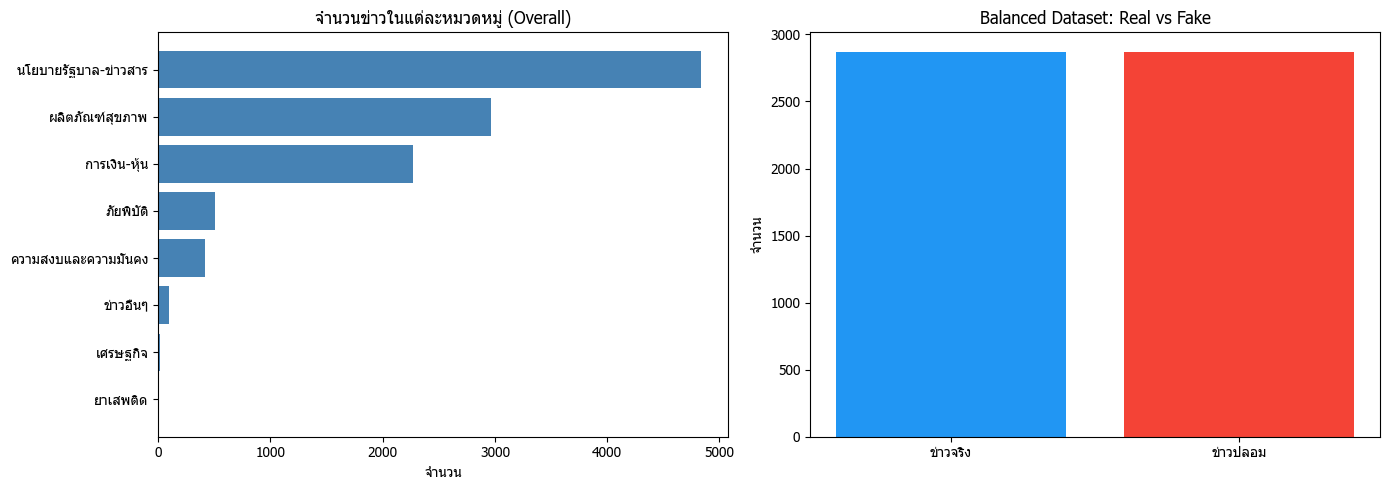

In [5]:
# ════════════════════════════════════════════
# STEP 3 — Balance Dataset
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 3 | Balance Dataset  (เลือกข่าวล่าสุด)")
print("="*60)
 
DATE_COL = 'วันและเวลาที่เผยแพร่'
 
def convert_thai_date(date_str):
    """แปลง พ.ศ. → ค.ศ. แล้วคืน string สำหรับ pd.to_datetime"""
    if pd.isna(date_str):
        return pd.NaT
    s = str(date_str).strip()
    if s == 'NaT':
        return pd.NaT
    if ' ' in s:
        s = s.split(' ')[0]
    if '/' in s:
        parts = s.split('/')
        fixed = []
        for p in parts:
            if p.isdigit() and len(p) == 4 and int(p) > 2400:
                fixed.append(str(int(p) - 543))
            else:
                fixed.append(p)
        return "-".join(fixed)
    return s
 
# แปลงวันที่
if DATE_COL in df.columns:
    df['parsed_date'] = pd.to_datetime(
        df[DATE_COL].apply(convert_thai_date),
        dayfirst=True, errors='coerce'
    )
    use_date = df['parsed_date'].notna().sum() > 0
else:
    use_date = False
 
idx_real = np.where(y_np == 0)[0]
idx_fake = np.where(y_np == 1)[0]
min_len  = min(len(idx_real), len(idx_fake))
 
def _pick_balanced(indices, sort_col, n):
    if sort_col:
        rows = df.iloc[indices].sort_values(by=sort_col, ascending=False)
        return rows.head(n).index.to_numpy()
    return indices[:n]
 
sort_col = 'parsed_date' if use_date else None
idx_real_b = _pick_balanced(idx_real, sort_col, min_len)
idx_fake_b = _pick_balanced(idx_fake, sort_col, min_len)
 
idx_balanced = np.concatenate([idx_real_b, idx_fake_b])
x_balanced   = x_np[idx_balanced]
y_balanced   = y_np[idx_balanced]
y_cat_balanced = y_cat_np[idx_balanced]
N_balanced   = len(x_balanced)
 
print(f"Balanced size: {N_balanced}  (จริง: {min_len}, ปลอม: {min_len})")
 
 
# ─────────────────────────────────────────────
# STEP 3b — Visualize Class & Category Distribution
# ─────────────────────────────────────────────
try:
    plt.rcParams['font.family'] = 'Tahoma'
except Exception:
    pass
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# กราฟ 1: Overall category
cat_counts = df['หมวดหมู่ของข่าว'].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='steelblue')
axes[0].set_title('จำนวนข่าวในแต่ละหมวดหมู่ (Overall)')
axes[0].set_xlabel('จำนวน')
 
# กราฟ 2: Balanced label
label_counts = pd.Series(y_balanced).map(id2label).value_counts()
axes[1].bar(label_counts.index, label_counts.values,
            color=['#2196F3', '#F44336'])
axes[1].set_title('Balanced Dataset: Real vs Fake')
axes[1].set_ylabel('จำนวน')
 
plt.tight_layout()
plt.savefig('img/graph_distribution.png', dpi=150)
plt.show()

Split → Train: 4020 | Val: 862 | Test: 862


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_12412\1403406323.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


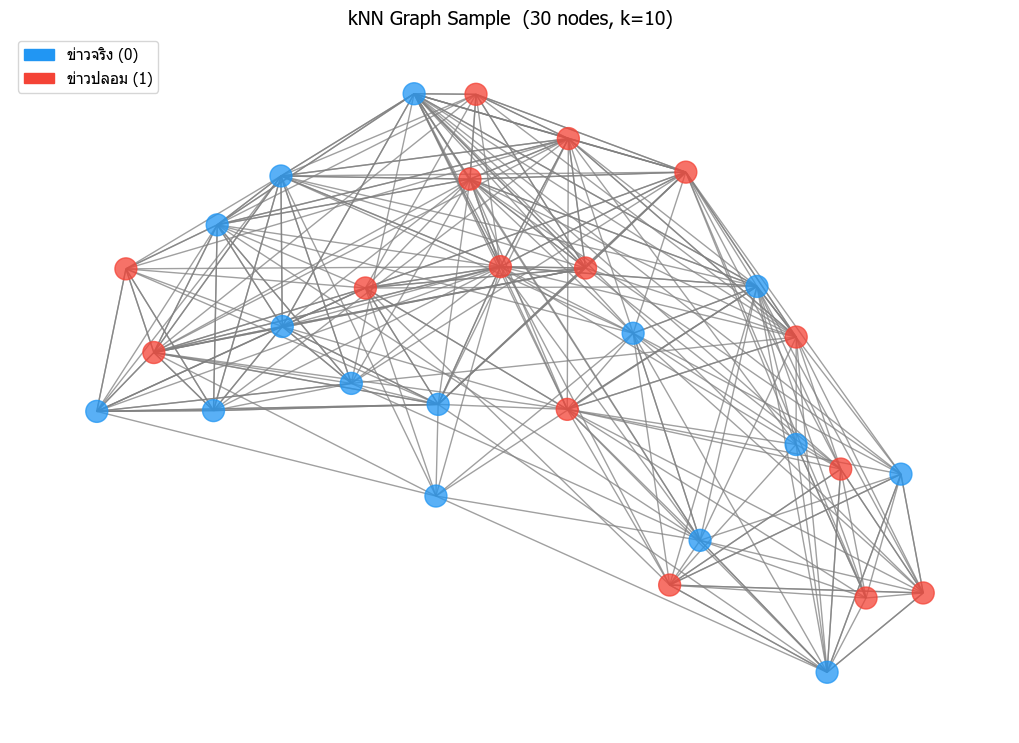

In [6]:
# ════════════════════════════════════════════
# STEP 4 — Train / Val / Test Split
# ════════════════════════════════════════════
K = 10

idx_all = np.arange(N_balanced)
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30,
                                        stratify=y_balanced, random_state=42)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50,
                                        stratify=y_balanced[idx_temp], random_state=42)

x_train, y_train = x_balanced[idx_train], y_balanced[idx_train]
x_val,   y_val   = x_balanced[idx_val],   y_balanced[idx_val]
x_test,  y_test  = x_balanced[idx_test],  y_balanced[idx_test]
y_cat_train      = y_cat_balanced[idx_train]
y_cat_val        = y_cat_balanced[idx_val]
y_cat_test       = y_cat_balanced[idx_test]

print(f"Split → Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")


# ── Visualize kNN Graph (sample 30 nodes) ────────────────
try:
    import networkx as nx
    from matplotlib.patches import Patch

    # 1) สุ่ม sample index จาก balanced data
    sample_n   = min(30, N_balanced)
    sample_idx = np.random.choice(N_balanced, sample_n, replace=False)  # (30,)
    x_sample   = x_balanced[sample_idx]                                  # (30, 768)
    y_sample   = y_balanced[sample_idx]                                  # (30,)

    # 2) สร้าง kNN บน sample (k+1 เพราะรวมตัวเอง)
    knn_vis = NearestNeighbors(n_neighbors=min(K + 1, sample_n),
                                metric='cosine').fit(x_sample)
    _, nbr_idx = knn_vis.kneighbors(x_sample)   # (30, k+1)

    # 3) สร้าง edge list (local index 0..29)
    #    nbr_idx[:, 0] = ตัวเอง → skip
    src_list, dst_list = [], []
    for local_i, neighbors in enumerate(nbr_idx[:, 1:]):   # skip col 0 (self)
        for local_j in neighbors:
            src_list.append(local_i)
            dst_list.append(local_j)

    # 4) สร้าง NetworkX graph (node = local index)
    G = nx.DiGraph()
    G.add_nodes_from(range(sample_n))
    G.add_edges_from(zip(src_list, dst_list))

    # 5) สี node ตาม label
    color_map = ["#2196F3" if y_sample[n] == 0 else "#F44336"
                 for n in range(sample_n)]

    # 6) วาด
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos,
            node_color=color_map,
            node_size=250,
            edge_color='gray',
            alpha=0.75,
            with_labels=False,
            arrows=False)

    legend_handles = [
        Patch(color='#2196F3', label=f'{id2label[0]} (0)'),
        Patch(color='#F44336', label=f'{id2label[1]} (1)'),
    ]
    plt.legend(handles=legend_handles, loc='upper left', fontsize=11)
    plt.title(f'kNN Graph Sample  ({sample_n} nodes, k={K})', fontsize=14)
    plt.tight_layout()
    plt.savefig('img/graph_knn_sample.png', dpi=150)
    plt.show()

except Exception as e:
    print(f"Graph visualization skipped: {e}")

In [7]:
# ════════════════════════════════════════════
# STEP 5 — Define GCN Model
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 5 | GCN Model Setup")
print("="*60)
 
model_gnn = GCNNet(
    in_channels     = 768,
    hidden_channels = 256,
    out_channels    = 2,
    dropout_rate    = 0.4,
).to(device)
 
optimizer = torch.optim.Adam(
    model_gnn.parameters(), lr=1e-3, weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=10, factor=0.5, verbose=True
)
 
# Class weight (กัน imbalanced ถ้ายังไม่ balanced สมบูรณ์)
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    1.0 / class_counts, dtype=torch.float, device=device
)
class_weights /= class_weights.sum()
criterion = nn.CrossEntropyLoss(weight=class_weights)
 
print(f"Model params: {sum(p.numel() for p in model_gnn.parameters()):,}")
print(f"Class weights: {class_weights.cpu().numpy()}")


STEP 5 | GCN Model Setup
Model params: 197,378
Class weights: [0.5 0.5]


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\venv-gpu\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



STEP 6 | Inductive Training  (Star Graph per query node)
 Epoch |     Loss |  Train Acc |    Val Acc | LR
------------------------------------------------------------
     1 |   0.3911 |     0.8269 |     0.8271 | 1.00e-03
    10 |   0.2734 |     0.8719 |     0.8503 | 1.00e-03
    20 |   0.2513 |     0.8823 |     0.8527 | 5.00e-04
    30 |   0.2461 |     0.8858 |     0.8677 | 5.00e-04
    40 |   0.2383 |     0.8900 |     0.8596 | 5.00e-04
    50 |   0.2305 |     0.8910 |     0.8654 | 2.50e-04
    60 |   0.2232 |     0.8970 |     0.8666 | 2.50e-04
    70 |   0.2181 |     0.8998 |     0.8724 | 1.25e-04
    80 |   0.2137 |     0.9055 |     0.8724 | 6.25e-05

Early stopping at epoch 85 (no improvement for 20 epochs)
------------------------------------------------------------
Best Val Acc: 0.8770


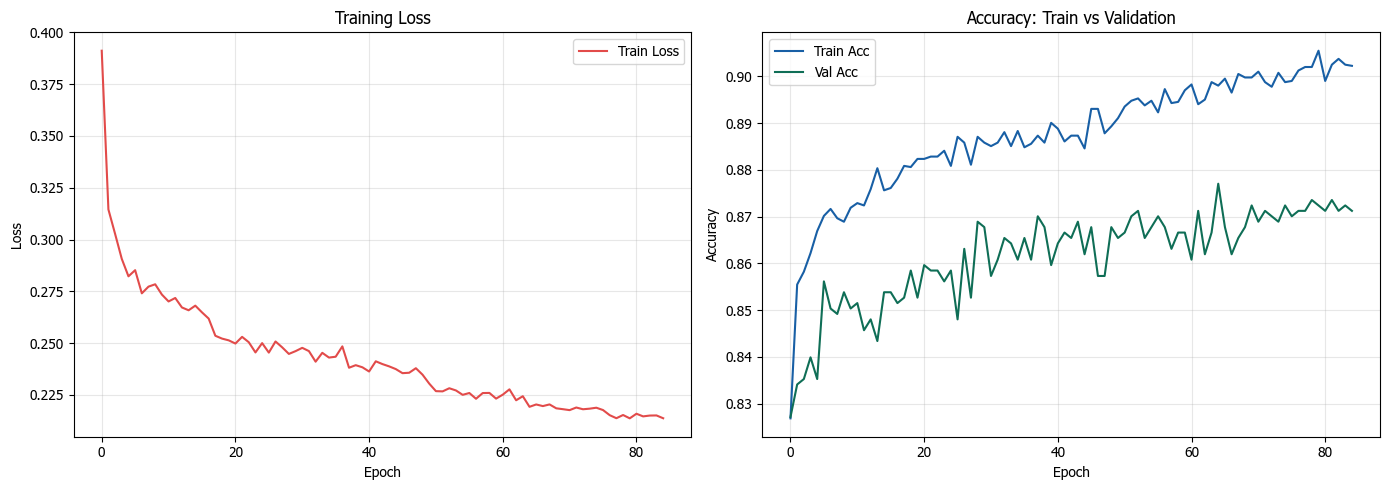

In [8]:
# ════════════════════════════════════════════
# STEP 6 — Inductive Training Loop
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 6 | Inductive Training  (Star Graph per query node)")
print("="*60)
 
# Support kNN จาก TRAIN เท่านั้น (ป้องกัน data leakage)
support_nbrs = NearestNeighbors(
    n_neighbors=K + 1, metric='cosine', algorithm='brute'
).fit(x_train)
 
EPOCHS     = 100
BATCH_SIZE = 32
PATIENCE   = 20
 
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc     = 0.0
patience_counter = 0
 
print(f"{'Epoch':>6} | {'Loss':>8} | {'Train Acc':>10} | {'Val Acc':>10} | LR")
print("-" * 60)
 
for epoch in range(1, EPOCHS + 1):
 
    # ── Train ──
    train_loss, train_acc = train_epoch_inductive(
        model        = model_gnn,
        optimizer    = optimizer,
        criterion    = criterion,
        x_query      = x_train,
        y_query      = y_train,
        x_support    = x_train,      # support = train only
        support_nbrs = support_nbrs,
        k            = K,
        device       = device,
        batch_size   = BATCH_SIZE,
    )
 
    # ── Validate ──
    val_acc, _, _ = eval_epoch_inductive(
        model        = model_gnn,
        x_query      = x_val,
        y_query      = y_val,
        x_support    = x_train,
        support_nbrs = support_nbrs,
        k            = K,
        device       = device,
    )
 
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
 
    scheduler.step(val_acc)
 
    # ── Save best ──
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model_gnn.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
 
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch:>6} | {train_loss:>8.4f} | {train_acc:>10.4f} | "
              f"{val_acc:>10.4f} | {current_lr:.2e}")
 
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break
 
print("-" * 60)
print(f"Best Val Acc: {best_val_acc:.4f}")
 
# ── Plot training curves ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], color='#E24B4A', label='Train Loss')
axes[0].set_title('Training Loss');   axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss');           axes[0].legend(); axes[0].grid(alpha=0.3)
 
axes[1].plot(history['train_acc'], color='#185FA5', label='Train Acc')
axes[1].plot(history['val_acc'],   color='#0F6E56', label='Val Acc')
axes[1].set_title('Accuracy: Train vs Validation')
axes[1].set_xlabel('Epoch');          axes[1].set_ylabel('Accuracy')
axes[1].legend();                     axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('img/graph_training_curves.png', dpi=150)
plt.show()


STEP 7 | Evaluation
โหลด 4 keys จากทั้งหมด 4 keys
              precision    recall  f1-score   support

    ข่าวจริง     0.9066    0.8329    0.8682       431
    ข่าวปลอม     0.8455    0.9142    0.8785       431

    accuracy                         0.8735       862
   macro avg     0.8760    0.8735    0.8733       862
weighted avg     0.8760    0.8735    0.8733       862



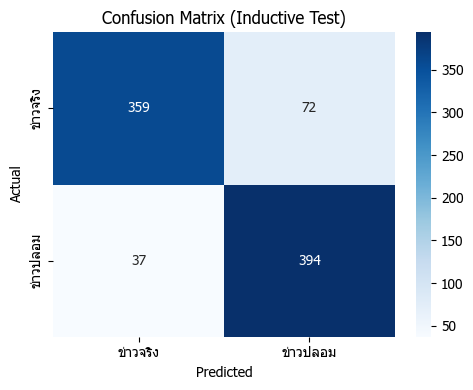


Test Accuracy (Inductive): 0.8735


In [9]:
# ════════════════════════════════════════════
# STEP 7 — Evaluation
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 7 | Evaluation")
print("="*60)
 
sd = torch.load('best_model.pth', map_location=device, weights_only=False)

# เก็บแค่ key ที่ GCNNet ต้องการ
gcn_keys = set(model_gnn.state_dict().keys())
sd_filtered = {k: v for k, v in sd.items() if k in gcn_keys}

model_gnn.load_state_dict(sd_filtered, strict=True)
print(f"โหลด {len(sd_filtered)} keys จากทั้งหมด {len(sd)} keys")

test_acc, y_true_i, y_pred_i = eval_epoch_inductive(
    model        = model_gnn,
    x_query      = x_test,
    y_query      = y_test,
    x_support    = x_train,
    support_nbrs = support_nbrs,
    k            = K,
    device       = device,
)

print(classification_report(y_true_i, y_pred_i,
                             target_names=[id2label[0], id2label[1]], digits=4))
 
# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_true_i, y_pred_i)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[id2label[0], id2label[1]],
            yticklabels=[id2label[0], id2label[1]])
ax.set_title('Confusion Matrix (Inductive Test)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('img/graph_confusion_matrix.png', dpi=150)
plt.show()
 
print(f"\nTest Accuracy (Inductive): {test_acc:.4f}")

In [10]:
# ══════════════════════════════════════════════
# STEP 8 — Predict New News
# ══════════════════════════════════════════════

# fit kNN บน x_train เท่านั้น (ไม่ใช่ x_balanced)
inference_nbrs = NearestNeighbors(
    n_neighbors=K, metric='cosine'
).fit(x_train)   # ← อยู่นอกฟังก์ชันได้ (fit ครั้งเดียว)


def predict_news(title: str, content: str = "", topn: int = K) -> dict:
    emb = embed_combined(title, content, tokenizer, lm_model, device)

    # ── kNN Search ← ต้องอยู่ในฟังก์ชัน ใช้ emb จากบรรทัดบน
    dists, idxs_2d = inference_nbrs.kneighbors(emb.reshape(1, -1), n_neighbors=topn)
    idxs  = idxs_2d[0]   # ไม่ต้อง skip เพราะ query ไม่อยู่ใน x_train
    dists = dists[0]

    # ── Category Prediction (majority vote) ──────────────
    neighbor_cats = [id2cat[cid] for cid in y_cat_train[idxs]]  # ← y_cat_train
    pred_category = Counter(neighbor_cats).most_common(1)[0][0]
 
    # ── Build Star Graph ─────────────────────────────────
    x_nodes = np.vstack([emb, x_balanced[idxs]])   # (topn+1, 768)
    nb      = np.arange(1, topn + 1)
    src     = np.concatenate([np.zeros(topn, dtype=np.int64), nb])
    dst     = np.concatenate([nb, np.zeros(topn, dtype=np.int64)])
    w       = 1.0 - dists
    w_both  = np.concatenate([w, w])
 
    data_new = Data(
        x          = torch.tensor(x_nodes,              dtype=torch.float, device=device),
        edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long,  device=device),
        edge_attr  = torch.tensor(w_both,               dtype=torch.float, device=device),
    )
 
    # ── GCN Inference ─────────────────────────────────────
    model_gnn.eval()
    with torch.no_grad():
        logits = model_gnn(data_new)
        probas = torch.softmax(logits, dim=1)[0].cpu().numpy()
 
    pred_id = int(np.argmax(probas))
 
    return {
        'label':         id2label[pred_id],
        'probability':   float(probas[pred_id]),
        'proba_all':     probas.tolist(),
        'category':      pred_category,
        'neighbor_cats': neighbor_cats,
        'pred_id':       pred_id,
    }
 
 
# ── Test Samples ─────────────────────────────────────────
test_news_data = [
    # ข่าวจริง (label 0)
    {"title": "ททท. เปิดตัว ลิซ่า เป็นตัวแทนการท่องเที่ยวไทย Amazing Thailand Ambassador", "label_true": 0},
    {"title": "สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลังพังถล่มจากฝนตกหนัก",          "label_true": 0},
    {"title": "อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม",                                        "label_true": 0},
    {"title": "ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' คึกคัก รายได้ทะลุ 22,000 ล้านบาท",                   "label_true": 0},
    # ข่าวปลอม (label 1)
    {"title": "ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย",                                         "label_true": 1},
    {"title": "การดื่มน้ำมะนาวสามารถทำลายมะเร็งเนื้อร้ายที่รุนแรงได้",                                 "label_true": 1},
    {"title": "ผู้สูงอายุ 60 ปีขึ้นไป รับเงินอุดหนุนพิเศษ 3,000 บาท ไม่ต้องลงทะเบียน",               "label_true": 1},
    {"title": "กินถั่วลิสงวันละ 1 กำมือ ช่วยรักษาอาการวัยทอง อารมณ์แปรปรวน",                         "label_true": 1},
    ]
 
y_true_batch, y_pred_batch = [], []
print(f"\n{'─'*70}")
print(f"{'#':<4} {'TRUE':<12} {'PRED':<12} {'CONF':>6}  {'HEADLINE'}")
print(f"{'─'*70}")
 
for i, news in enumerate(test_news_data):
    try:
        result = predict_news(news['title'])
        y_true_batch.append(news['label_true'])
        y_pred_batch.append(result['pred_id'])
 
        ok = "✅" if result['pred_id'] == news['label_true'] else "❌"
        true_lbl = id2label[news['label_true']]
        print(f"{ok} {i+1:<3} {true_lbl:<12} {result['label']:<12} "
              f"{result['probability']:>5.1%}  {news['title'][:45]}...")
    except Exception as e:
        print(f"  [{i+1}] ERROR: {e}")
 
# Summary metrics
if y_pred_batch:
    print(f"\n{'─'*40}")
    print(classification_report(y_true_batch, y_pred_batch,
                                 target_names=[id2label[0], id2label[1]],
                                 zero_division=0))


──────────────────────────────────────────────────────────────────────
#    TRUE         PRED           CONF  HEADLINE
──────────────────────────────────────────────────────────────────────
❌ 1   ข่าวจริง     ข่าวปลอม     71.8%  ททท. เปิดตัว ลิซ่า เป็นตัวแทนการท่องเที่ยวไทย...
❌ 2   ข่าวจริง     ข่าวปลอม     73.4%  สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโน...
✅ 3   ข่าวจริง     ข่าวจริง     73.0%  อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม...
✅ 4   ข่าวจริง     ข่าวจริง     63.6%  ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' คึกคัก รายไ...
✅ 5   ข่าวปลอม     ข่าวปลอม     63.1%  ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย...
✅ 6   ข่าวปลอม     ข่าวปลอม     65.6%  การดื่มน้ำมะนาวสามารถทำลายมะเร็งเนื้อร้ายที่ร...
✅ 7   ข่าวปลอม     ข่าวปลอม     67.0%  ผู้สูงอายุ 60 ปีขึ้นไป รับเงินอุดหนุนพิเศษ 3,...
✅ 8   ข่าวปลอม     ข่าวปลอม     81.8%  กินถั่วลิสงวันละ 1 กำมือ ช่วยรักษาอาการวัยทอง...

────────────────────────────────────────
              precision    recall  f1-score   support

    ข่าวจ

ตัดข้อมูลให้เท่ากัน (Balancing)

สร้างกราฟ (kNN Graph)

แบ่งข้อมูล (Train/Test Split)

สร้าง data object เตรียมเข้าโมเดล

In [11]:
# ════════════════════════════════════════════
# STEP 9 — Save Artifacts
# ════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 9 | Save Artifacts")
print("="*60)
 
artifacts = {
    # Support set: train split เท่านั้น (ป้องกัน data leakage)
    "x_np":       x_train_np,    # train only
    "y_label_np": y_train_np,
    "y_cat_np":   y_cat_train,
    # Mappings
    'id2label':   id2label,
    'label2id':   label2id,
    'id2cat':     id2cat,
    'cat2id':     cat2id,
    # Hyperparams
    'k':          K,
}
 
with open('artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
 
torch.save(model_gnn.state_dict(), 'best_model.pth')
 
print(f"Saved: artifacts.pkl  (support = {len(x_train)} train samples)")
print(f"Saved: best_model.pth")
print(f"\nPipeline complete.")


STEP 9 | Save Artifacts
Saved: artifacts.pkl  (support = 4020 train samples)
Saved: best_model.pth

Pipeline complete.
